# Speeding up the objective function calculation using numba

The objective function is evaluated over and over again and it makes sense to spent some time to make it faster. Here we use the just-in-time compilation option from `numba`.


## The n-Queens Problem

* __Goal:__ Find an arrangement of $n$ queens on a $n \times n$ chess board so that no queen is on the same row, column or diagonal as any other queen.

* __State space:__ An arrangement of the queens on the board. We restrict the state space to arrangements where there is only a single queen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the queens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two queens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ queens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one queen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one queen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum. 

## Objective function calculation

### Naive $O(n^2)$ Implementation
Naive implementation with nested loops. This is $O(n^2)$.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import math

In [11]:
def conflicts_naive(board):
    """Calculate the number of conflicts, i.e., the objective function."""
    
    board = np.array(board)
    
    n = len(board)
    val = 0

    # check horizontal (we do not check vertical since the state space is restricted to one queen per col)
    for i in range(n): val += math.comb(np.sum(board == i), 2)
    #print(f"Horizontal value: {val}")
    
    # check for each queen diagonally up and down (only to the right side of the queen)
    for j in range(n):
        q_up = board[j]
        q_down = board[j]
     
        for jj in range(j+1, n):
            q_up -= 1
            q_down += 1
            if board[jj] == q_up: val += 1
            if board[jj] == q_down: val += 1
        #print(f"Value after queen {j}: {val}")
       
    return(val)    

Triển khai naive với độ phức tạp O(n²):
  - Kiểm tra xung đột theo hàng bằng cách đếm số quân hậu trên mỗi hàng
  - Kiểm tra xung đột theo đường chéo bằng cách duyệt qua từng cặp quân hậu
  - Sử dụng `math.comb()` để tính số xung đột từ số lượng quân hậu

### $O(n)$ Implementation

A better implementation that should be $O(n)$. Idea: 

1. Count how many queens are in each row (no need to check columns) and how many are in each diagonal.
2. Convert the number of $n$ queens in a row (diagonal) into the numbner of pariwise conflicts in $n$ choose 2. We use a faster special case for the `comb()` function to calcualte the conflicts given the number of queens.   

In [12]:
def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)
    
    horizontal_cnt = [0] * n
    # we have double the diagonals compared to columns!
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n
    
    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1
    
    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

Triển khai O(n) hiệu quả hơn:
  - Đếm số quân hậu trên mỗi hàng/đường chéo trong một lần duyệt
  - Sử dụng `comb2()` thay vì `math.comb()` để tối ưu tốc độ
  - Chuyển đổi số lượng quân hậu thành số xung đột cặp

### Compiled $O(n)$ Implementation
We can use just-in-time compilation for the conflicts function. Code provided by Troy McNitt.

In [13]:
from numba import njit

# with jit (cannot use some Python functions like sum and map)
@njit()
def comb2_jit(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

@njit()
def conflicts_jit(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)
 
    cnt = [0] * (5 * n)
 
    for i in range(n):
        cnt[board[i]] += 1
        cnt[(n) + (i + board[i])] += 1
        cnt[(3 * n) + (i - board[i] + n)] += 1
 
    conflicts = 0
    for x in cnt:
        conflicts += comb2_jit(x)
 
    return conflicts

Sử dụng biên dịch JIT với numba:
  - Decorator `@njit()` để biên dịch just-in-time
  - Tối ưu hóa tốc độ thực thi đáng kể
  - Không thể sử dụng một số hàm Python như `sum()` và `map()`

# Compare Timing

Compare runtime on 50 random boards of different sizes.

In [14]:
np.random.seed(1234)
def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""
    
    return(np.random.randint(0,n, size = n))

In [15]:
import timeit
 
# run it once to force compilation
conflicts_jit(random_board(4))
    
reps = 20
x = []
naive_times = []
linear_times = []
jit_times = []
 
 
for i in [8] + list(range(50, 500, 50)):
    # do reps replications on random boards
    boards = [random_board(i) for _ in range(reps)]
 
    #print(f"Doing: {i}")

    # number = 1 means we only run it once in timeit 
    naive = timeit.timeit(
        lambda: [conflicts_naive(board) for board in boards], number=1
    )
    linear = timeit.timeit(
        lambda: [conflicts(board) for board in boards], number=1
    )
    jit = timeit.timeit(
        lambda: [conflicts_jit(board) for board in boards], number=1
    )

 
    x.append(i)
    naive_times.append(naive)
    linear_times.append(linear)
    jit_times.append(jit)

# average time per board in microseconds
naive_times = np.array(naive_times) / reps * 1e6
linear_times = np.array(linear_times) / reps * 1e6
jit_times = np.array(jit_times) / reps * 1e6

print("Times for 8x8 board in microseconds")
print(f'naive: {naive_times[0]}, linear: {linear_times[0]}, jit: {jit_times[0]}')
 

Times for 8x8 board in microseconds
naive: 309.76499999724183, linear: 348.2650000023568, jit: 4.429999989952194


- JIT nhanh nhất: Nhanh hơn naive ~70 lần, nhanh hơn linear ~79 lần
- Linear vs Naive: Linear chậm hơn naive một chút cho bàn cờ 8x8, có thể do overhead của việc tạo danh sách và sử dụng `map()`
- JIT hiệu quả: Biên dịch JIT mang lại cải thiện hiệu suất đáng kể

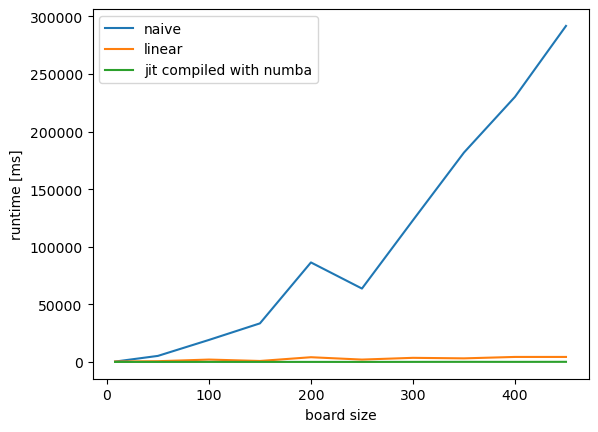

In [16]:
plt.plot(x, naive_times)
plt.plot(x, linear_times)
plt.plot(x, jit_times)
plt.xlabel("board size")
plt.ylabel("runtime [ms]")
plt.legend(["naive", "linear", "jit compiled with numba"])
plt.show()

- Triển khai `naive` O(n²):
  + Thời gian chạy tăng theo hàm bậc hai, đạt gần 300,000 ms (5 phút) ở kích thước bàn cờ 450
  + Hoàn toàn không thực tế cho các bài toán lớn
  + Thể hiện đúng đặc tính O(n²) của thuật toán
- Triển khai `linear` O(n):
  + Thời gian chạy tăng tuyến tính và ổn định
  + Luôn dưới 5,000 ms trong toàn bộ phạm vi
  + Cải thiện đáng kể so với naive implementation
- Triển khai `jit compiled with numba` O(n):
  + Thời gian chạy gần như không đổi và cực kỳ thấp
  + Gần như trùng với trục X
  + Hiệu suất vượt trội nhất

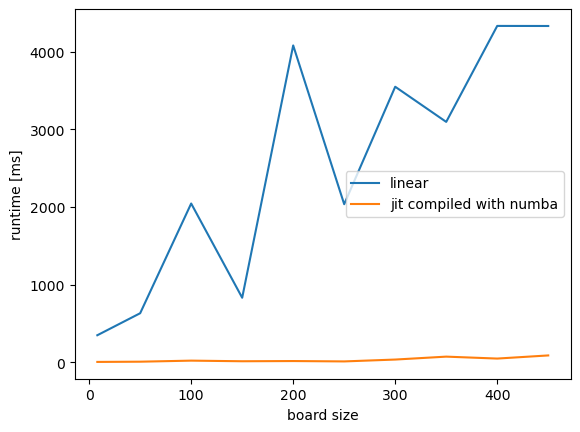

In [17]:
plt.plot(x, linear_times)
plt.plot(x, jit_times)
plt.xlabel("board size")
plt.ylabel("runtime [ms]")
plt.legend(["linear", "jit compiled with numba"])
plt.show()

- Triển khai `linear`:
  + Thời gian chạy dao động từ 300ms đến 4,300ms
  + Có sự biến động lớn và không ổn định
  + Đạt đỉnh cao nhất ở khoảng 4,100ms khi board size 200
- Triển khai `jit compiled with numba`:
  + Thời gian chạy luôn duy trì dưới 100ms
  + Chủ yếu trong khoảng 0-50ms
  + Cực kỳ ổn định trên toàn bộ phạm vi
  + Thể hiện hiệu quả của JIT compilation